# 01 — OT-CFM: Optimal Transport Conditional Flow Matching

OT-CFM implementation from scratch on CIFAR-10, reusing the same U-Net from DDPM.

**Sections:**
1. Theory
2. Interpolation & Velocity (with σ_min)
3. Model (same U-Net, t ∈ [0,1])
4. Training
5. ODE Solver (torchdiffeq)
6. Sampling & Visualization

**Run locally up to section 3. Train on Colab.**

In [ ]:
import math
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from dataclasses import dataclass

try:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
except ModuleNotFoundError:
    pass

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

In [ ]:
@dataclass
class CFMConfig:
    image_size: int = 32
    channels: int = 3
    model_channels: int = 128
    num_heads: int = 4
    dropout: float = 0.1
    num_groups: int = 32
    sigma_min: float = 0.0   # 0.0 = deterministic OT path
    batch_size: int = 128
    lr: float = 2e-4
    num_epochs: int = 500
    grad_clip: float = 1.0
    ema_decay: float = 0.9999
    clip_denoised: bool = True

cfg = CFMConfig()
cfg_tiny = CFMConfig(model_channels=32, num_heads=2, num_groups=8)

---
## Section 1: OT-CFM Theory

### The idea

DDPM learns to **denoise**: given a noisy image, predict the noise that was added.

OT-CFM learns a **velocity field**: given a point along an optimal transport path from noise to data, predict the direction to move.

### The conditional flow map (eq. 22 from Lipman et al.)

OT-CFM defines a conditional probability path via the **flow map** ψ_t:

> `xₜ = ψ_t(x₀) = (1 - (1-σ_min)·t) · x₀ + t · x₁`

where σ_min ≥ 0 is a small constant controlling residual noise at t=1.

At `t=0`: `x₀` (pure noise).  
At `t=1`: `σ_min · x₀ + x₁` (nearly clean — exactly clean when σ_min=0).

**When σ_min = 0**, this reduces to the simple straight line: `xₜ = (1-t)·x₀ + t·x₁`

### The velocity target (eq. 23)

The target velocity along this path is **constant** (independent of t!):

> `uₜ = x₁ - (1-σ_min) · x₀`

**When σ_min = 0**, this reduces to: `uₜ = x₁ - x₀`

### The training objective (eq. 23)

Train a neural network `v_θ(xₜ, t)` to predict this velocity:

> `L = E_{t, x₀, x₁} || v_θ(ψ_t(x₀), t) - (x₁ - (1-σ_min)·x₀) ||²`

### Sampling

Start from `x₀ ~ N(0, I)` and solve the ODE `dx/dt = v_θ(x, t)` from `t=0` to `t=1`.

### σ_min values
- **σ_min = 0.0**: Deterministic OT path. Simplest. Used by TorchCFM for CIFAR-10.
- **σ_min = 1e-5 or 0.001**: Adds tiny residual noise for numerical stability.

### Comparison

| | DDPM | OT-CFM |
|---|---|---|
| Time | t ∈ {0,...,999} discrete | t ∈ [0, 1] continuous |
| Path | xₜ = √ᾱₜ·x₀ + √(1-ᾱₜ)·ε | xₜ = (1-(1-σ_min)t)·x₀ + t·x₁ |
| Target | noise ε | velocity x₁ - (1-σ_min)·x₀ |
| Schedule | cosine/linear (many params) | just σ_min |
| Sampling | fixed reverse process | any ODE solver |

---
## Section 2: Interpolation & Velocity Target

Unlike DDPM, OT-CFM doesn't need a NoiseScheduler class. Just two formulas with σ_min.

In [ ]:
def cfm_interpolate(x0: torch.Tensor, x1: torch.Tensor, t: torch.Tensor,
                    sigma_min: float = 0.0):
    """OT-CFM flow map ψ_t(x₀) — eq. 22, Lipman et al."""
    t = t.reshape(-1, 1, 1, 1)
    return (1 - (1 - sigma_min) * t) * x0 + t * x1


def cfm_velocity_target(x0: torch.Tensor, x1: torch.Tensor,
                        sigma_min: float = 0.0):
    """OT-CFM target velocity — eq. 23, Lipman et al."""
    return x1 - (1 - sigma_min) * x0

In [5]:
# Visualize the OT-CFM interpolation path as a smooth animation
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

raw_dataset = datasets.CIFAR10(root='./data', train=True, download=True,
                                transform=transforms.Compose([
                                    transforms.ToTensor(),
                                    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
                                ]))

torch.manual_seed(2)
x1, label = raw_dataset[3]       # real image (data)
x1 = x1.unsqueeze(0)             # [1, 3, 32, 32]
x0 = torch.randn_like(x1)        # noise

CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# Pre-compute frames at 100 time steps
num_frames = 100
frames = []
for i in range(num_frames + 1):
    t_val = i / num_frames
    t_tensor = torch.tensor([t_val])
    x_t = cfm_interpolate(x0, x1, t_tensor, sigma_min=cfg.sigma_min)
    img = ((x_t.squeeze() + 1) / 2).clamp(0, 1).permute(1, 2, 0).numpy()
    frames.append((t_val, img))

# Create animation
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(frames[0][1])
title = ax.set_title(f't = 0.00  (pure noise)', fontsize=13)
ax.axis('off')
fig.suptitle(f'OT-CFM path: noise → "{CLASSES[label]}" (σ_min={cfg.sigma_min})', fontsize=14)

def update(i):
    t_val, img = frames[i]
    im.set_data(img)
    if t_val < 0.1:
        label_txt = 'pure noise'
    elif t_val > 0.9:
        label_txt = 'clean image'
    else:
        label_txt = 'interpolating...'
    title.set_text(f't = {t_val:.2f}  ({label_txt})')
    return [im, title]

anim = FuncAnimation(fig, update, frames=len(frames), interval=50, blit=True)
plt.close(fig)
HTML(anim.to_jshtml())

100%|██████████| 170M/170M [00:03<00:00, 43.4MB/s] 


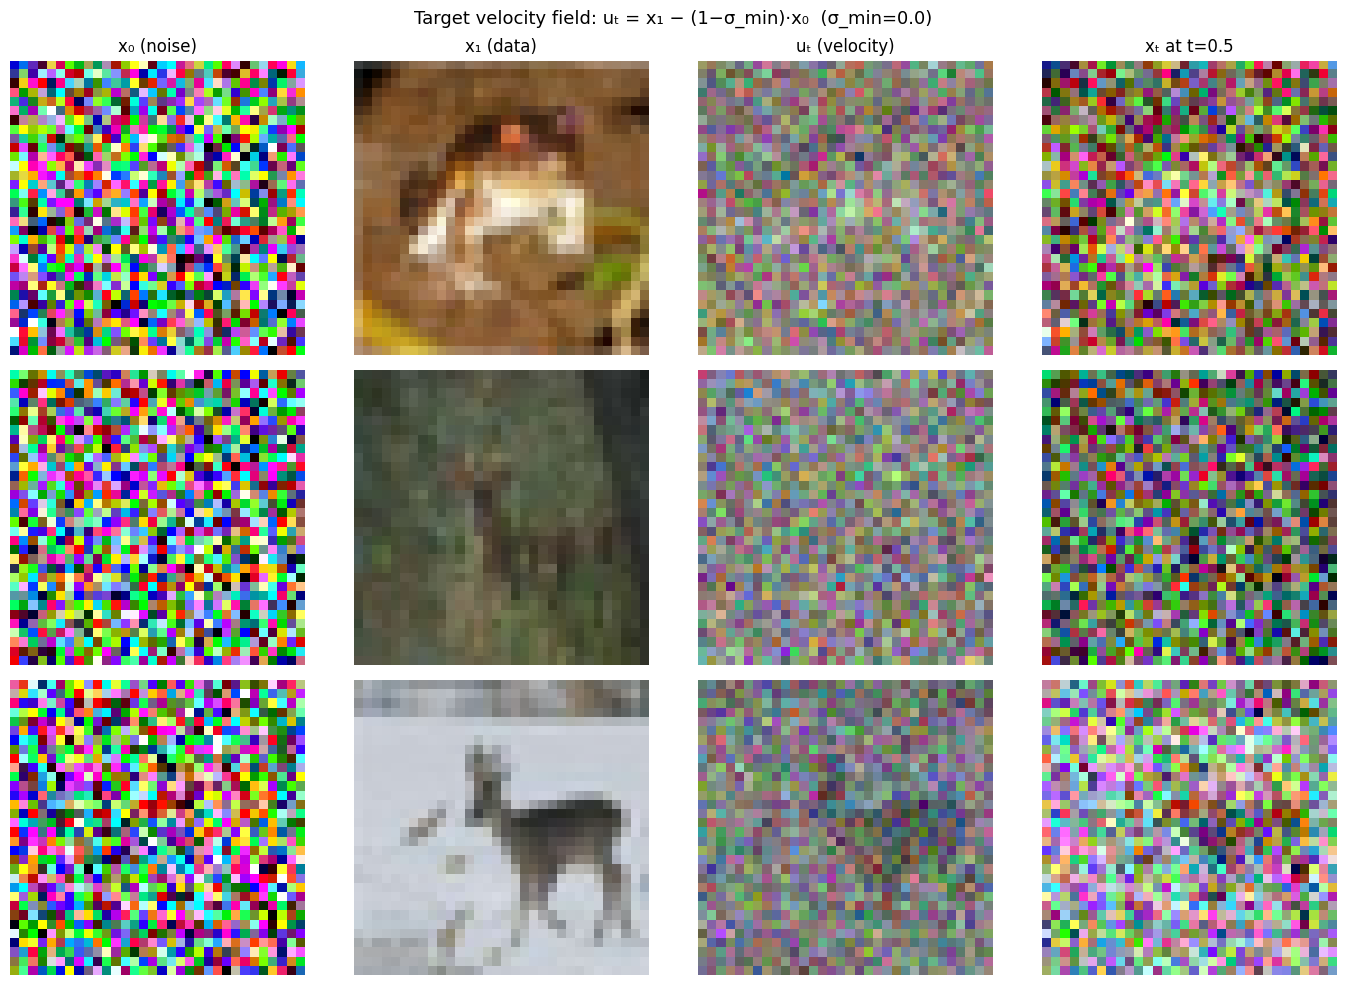

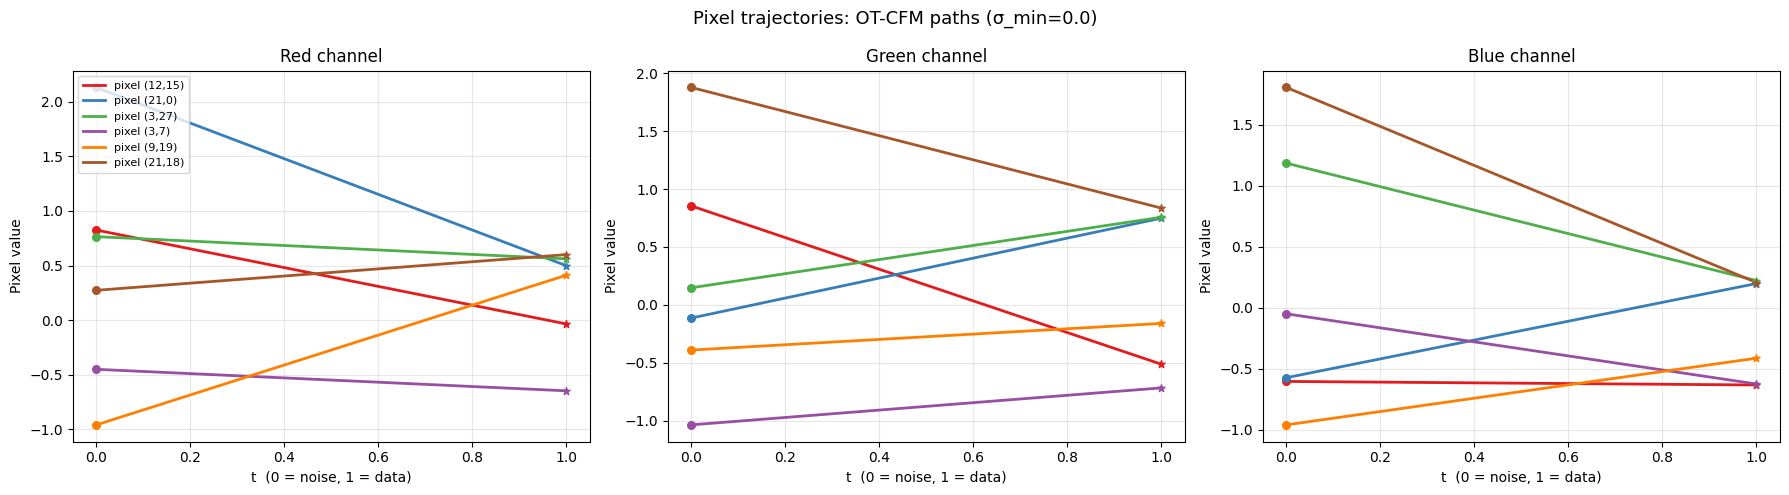

Every pixel follows a straight line from its noise value toward its data value.
With σ_min=0.0, at t=1 each pixel reaches σ_min·x₀ + x₁ (≈ x₁ when σ_min is small).


In [6]:
# Visualize the OT-CFM target velocity field uₜ = x₁ - (1-σ_min)·x₀
# Show it as: (1) per-pixel velocity image, (2) pixel trajectories over time

torch.manual_seed(0)

# --- Part A: Velocity as image (3 examples) ---
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle(f'Target velocity field: uₜ = x₁ − (1−σ_min)·x₀  (σ_min={cfg.sigma_min})', fontsize=13)
col_labels = ['x₀ (noise)', 'x₁ (data)', 'uₜ (velocity)', 'xₜ at t=0.5']

for row in range(3):
    x1_i, lbl = raw_dataset[row * 10]
    x1_i = x1_i.unsqueeze(0)
    x0_i = torch.randn_like(x1_i)
    u_t = cfm_velocity_target(x0_i, x1_i, sigma_min=cfg.sigma_min)
    x_mid = cfm_interpolate(x0_i, x1_i, torch.tensor([0.5]), sigma_min=cfg.sigma_min)

    images = [x0_i, x1_i, u_t, x_mid]
    for col, img_tensor in enumerate(images):
        img = img_tensor.squeeze()
        if col == 2:
            img_vis = (img - img.min()) / (img.max() - img.min())
        else:
            img_vis = ((img + 1) / 2).clamp(0, 1)
        axes[row, col].imshow(img_vis.permute(1, 2, 0).numpy())
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(col_labels[col], fontsize=12)

plt.tight_layout()
plt.show()

# --- Part B: Pixel trajectories — the actual PATHS ---
# Track how individual pixel RGB values travel from x₀ to x₁ over time
# OT-CFM: straight lines (slightly modified by σ_min)

torch.manual_seed(42)
x1_traj, _ = raw_dataset[7]
x1_traj = x1_traj.unsqueeze(0)
x0_traj = torch.randn_like(x1_traj)

# Pick 6 random pixels to track
np.random.seed(0)
pixel_coords = [(np.random.randint(0, 32), np.random.randint(0, 32)) for _ in range(6)]
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']

time_steps = torch.linspace(0, 1, 200)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Pixel trajectories: OT-CFM paths (σ_min={cfg.sigma_min})', fontsize=13)
channel_names = ['Red', 'Green', 'Blue']

for ch_idx in range(3):
    ax = axes[ch_idx]
    ax.set_title(f'{channel_names[ch_idx]} channel', fontsize=12)
    ax.set_xlabel('t  (0 = noise, 1 = data)')
    ax.set_ylabel('Pixel value')
    ax.grid(True, alpha=0.3)

    for px_idx, (py, px) in enumerate(pixel_coords):
        vals_cfm = []
        for t_val in time_steps:
            x_t = cfm_interpolate(x0_traj, x1_traj, t_val.unsqueeze(0), sigma_min=cfg.sigma_min)
            vals_cfm.append(x_t[0, ch_idx, py, px].item())

        ax.plot(time_steps.numpy(), vals_cfm, color=colors[px_idx],
                linewidth=2, label=f'pixel ({py},{px})' if ch_idx == 0 else None)

        ax.scatter([0], [vals_cfm[0]], color=colors[px_idx], s=30, zorder=5)
        ax.scatter([1], [vals_cfm[-1]], color=colors[px_idx], s=30, zorder=5, marker='*')

if axes[0].get_legend_handles_labels()[1]:
    axes[0].legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()
print('Every pixel follows a straight line from its noise value toward its data value.')
print(f'With σ_min={cfg.sigma_min}, at t=1 each pixel reaches σ_min·x₀ + x₁ (≈ x₁ when σ_min is small).')

---
## Section 3: Model

Same U-Net architecture as DDPM. The only difference:
- DDPM passes integer timesteps in {0, ..., 999}
- OT-CFM passes float time values in [0, 1]

The sinusoidal `TimeEmbedding` works with any scale of input — the network just learns different embedding weights during training.

Output is predicted velocity v̂ (not predicted noise ε̂ like in DDPM).

In [ ]:
class TimeEmbedding(nn.Module):
    def __init__(self, base_dim):
        super().__init__()
        self.base_dim = base_dim
        self.mlp = nn.Sequential(nn.Linear(base_dim, base_dim*4), nn.SiLU(), nn.Linear(base_dim*4, base_dim*4))
    def forward(self, t):
        half  = self.base_dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / (half - 1))
        emb   = t[:, None].float() * freqs[None]
        emb   = torch.cat([emb.sin(), emb.cos()], dim=-1)
        return self.mlp(emb)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, num_groups=32, dropout=0.1):
        super().__init__()
        self.norm1    = nn.GroupNorm(num_groups, in_ch)
        self.conv1    = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.time_mlp = nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, out_ch * 2))
        self.norm2    = nn.GroupNorm(num_groups, out_ch)
        self.dropout  = nn.Dropout(dropout)
        self.conv2    = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.act      = nn.SiLU()
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, t_emb):
        h = self.conv1(self.act(self.norm1(x)))
        scale, shift = self.time_mlp(t_emb).chunk(2, dim=-1)
        h = h * (scale[:, :, None, None] + 1) + shift[:, :, None, None]
        h = self.dropout(self.conv2(self.act(self.norm2(h))))
        return h + self.shortcut(x)

class SelfAttention(nn.Module):
    def __init__(self, channels, num_heads=4, num_groups=32):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = channels // num_heads
        self.norm      = nn.GroupNorm(num_groups, channels)
        self.to_qkv    = nn.Conv2d(channels, channels * 3, 1, bias=False)
        self.to_out    = nn.Conv2d(channels, channels, 1)
    def forward(self, x):
        B, C, H, W = x.shape
        h   = self.norm(x)
        qkv = self.to_qkv(h).reshape(B, 3, self.num_heads, self.head_dim, H * W).permute(1, 0, 2, 4, 3)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = F.scaled_dot_product_attention(q, k, v).permute(0, 1, 3, 2).reshape(B, C, H, W)
        return x + self.to_out(attn)

class Downsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 3, stride=2, padding=1)
    def forward(self, x): return self.conv(x)

class Upsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 3, padding=1)
    def forward(self, x): return self.conv(F.interpolate(x, scale_factor=2, mode='nearest'))

In [ ]:
class UNet(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        ch, t_dim, ng, nh, do = cfg.model_channels, cfg.model_channels*4, cfg.num_groups, cfg.num_heads, cfg.dropout
        self.time_emb = TimeEmbedding(ch)
        self.init_conv = nn.Conv2d(3, ch, 3, padding=1)
        self.enc1_a = ResBlock(ch,   ch,   t_dim, ng, do); self.enc1_b = ResBlock(ch,   ch,   t_dim, ng, do); self.down1 = Downsample(ch)
        self.enc2_a = ResBlock(ch,   ch*2, t_dim, ng, do); self.enc2_b = ResBlock(ch*2, ch*2, t_dim, ng, do); self.attn2 = SelfAttention(ch*2, nh, ng); self.down2 = Downsample(ch*2)
        self.enc3_a = ResBlock(ch*2, ch*2, t_dim, ng, do); self.enc3_b = ResBlock(ch*2, ch*2, t_dim, ng, do); self.attn3 = SelfAttention(ch*2, nh, ng); self.down3 = Downsample(ch*2)
        self.mid1 = ResBlock(ch*2, ch*2, t_dim, ng, do); self.mid_attn = SelfAttention(ch*2, nh, ng); self.mid2 = ResBlock(ch*2, ch*2, t_dim, ng, do)
        self.up3 = Upsample(ch*2); self.dec3_a = ResBlock(ch*4, ch*2, t_dim, ng, do); self.dec3_b = ResBlock(ch*2, ch*2, t_dim, ng, do); self.dattn3 = SelfAttention(ch*2, nh, ng)
        self.up2 = Upsample(ch*2); self.dec2_a = ResBlock(ch*4, ch*2, t_dim, ng, do); self.dec2_b = ResBlock(ch*2, ch*2, t_dim, ng, do); self.dattn2 = SelfAttention(ch*2, nh, ng)
        self.up1 = Upsample(ch*2); self.dec1_a = ResBlock(ch*3, ch,   t_dim, ng, do); self.dec1_b = ResBlock(ch,   ch,   t_dim, ng, do)
        self.out_norm = nn.GroupNorm(ng, ch); self.out_conv = nn.Conv2d(ch, 3, 1)
    def forward(self, x, t):
        t_emb = self.time_emb(t)
        h = self.init_conv(x)
        h = self.enc1_b(self.enc1_a(h, t_emb), t_emb);  s1 = h
        h = self.attn2(self.enc2_b(self.enc2_a(self.down1(h), t_emb), t_emb)); s2 = h
        h = self.attn3(self.enc3_b(self.enc3_a(self.down2(h), t_emb), t_emb)); s3 = h
        h = self.down3(h); h = self.mid1(h, t_emb); h = self.mid_attn(h); h = self.mid2(h, t_emb)
        h = self.dattn3(self.dec3_b(self.dec3_a(torch.cat([self.up3(h), s3], dim=1), t_emb), t_emb))
        h = self.dattn2(self.dec2_b(self.dec2_a(torch.cat([self.up2(h), s2], dim=1), t_emb), t_emb))
        h = self.dec1_b(self.dec1_a(torch.cat([self.up1(h), s1], dim=1), t_emb), t_emb)
        return self.out_conv(F.silu(self.out_norm(h)))


# Sanity check
torch.manual_seed(0)
model_tiny = UNet(cfg_tiny)
dummy_img = torch.randn(2, 3, 32, 32)
dummy_t = torch.rand(2)
with torch.no_grad():
    out = model_tiny(dummy_img, dummy_t)
assert out.shape == dummy_img.shape
print(f'UNet ok — in: {dummy_img.shape}, out: {out.shape}')

---
## Section 4: Training

**The OT-CFM training step (one batch):**
1. Sample `x₁ ~ data` (real images from batch)
2. Sample `x₀ ~ N(0, I)` (fresh noise, same shape)
3. Sample `t ~ U(0, 1)` (continuous time for each image)
4. Interpolate: `xₜ = (1 - (1-σ_min)·t) · x₀ + t · x₁`
5. Target velocity: `uₜ = x₁ - (1-σ_min) · x₀`
6. Predict: `v̂ = UNet(xₜ, t)`
7. Loss = MSE(v̂, uₜ)

Compare with DDPM:
- DDPM samples discrete t, uses noise schedule to corrupt, predicts noise
- OT-CFM samples continuous t, uses flow map with σ_min, predicts velocity

In [ ]:
class EMA:
    def __init__(self, model: nn.Module, decay: float = 0.9999):
        self.model  = model
        self.decay  = decay
        self.shadow = {name: param.data.clone()
                       for name, param in model.named_parameters()}
        self._backup = {}

    @torch.no_grad()
    def update(self):
        for name, param in self.model.named_parameters():
            self.shadow[name] = (
                self.decay * self.shadow[name] + (1 - self.decay) * param.data
            )

    def apply(self):
        for name, param in self.model.named_parameters():
            self._backup[name] = param.data.clone()
            param.data.copy_(self.shadow[name])

    def restore(self):
        for name, param in self.model.named_parameters():
            param.data.copy_(self._backup[name])
        self._backup = {}

In [ ]:
def compute_loss(model, x1, device, sigma_min=0.0):
    """OT-CFM training loss — eq. 23, Lipman et al."""
    x1 = x1.to(device)
    B = x1.shape[0]

    x0 = torch.randn_like(x1)
    t = torch.rand(B, device=device)
    x_t = cfm_interpolate(x0, x1, t, sigma_min)
    target_velocity = cfm_velocity_target(x0, x1, sigma_min)
    predicted_velocity = model(x_t, t)

    return F.mse_loss(predicted_velocity, target_velocity)

In [ ]:
DRIVE_DIR  = '/content/drive/MyDrive/flow-matching'
DRIVE_RUNS = f'{DRIVE_DIR}/runs/cfm'

def get_run_dir():
    if os.path.exists('/content/drive/MyDrive'):
        return DRIVE_RUNS
    return 'runs/cfm'


@torch.no_grad()
def _sample_for_progress(model, device, n=16, nfe=50):
    model.eval()
    return cfm_sample(model, (n, 3, 32, 32), device, method='midpoint', nfe=nfe)


def _save_grid(samples, path):
    imgs = ((samples.cpu() + 1) / 2).clamp(0, 1)
    torchvision.utils.save_image(
        torchvision.utils.make_grid(imgs, nrow=8, padding=2), path
    )

def _show_grid(samples, title=''):
    imgs = ((samples.cpu() + 1) / 2).clamp(0, 1)
    grid = torchvision.utils.make_grid(imgs, nrow=8, padding=2)
    plt.figure(figsize=(14, 4))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title(title); plt.axis('off'); plt.tight_layout(); plt.show()


def train_cfm(cfg: CFMConfig, run_dir: str = None, num_epochs: int = None):
    run_dir    = run_dir or get_run_dir()
    num_epochs = num_epochs or cfg.num_epochs

    os.makedirs(f'{run_dir}/checkpoints', exist_ok=True)
    os.makedirs(f'{run_dir}/samples',     exist_ok=True)

    transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    loader  = DataLoader(dataset, batch_size=cfg.batch_size, shuffle=True,
                         num_workers=4, pin_memory=True, drop_last=True)

    model     = UNet(cfg).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    ema       = EMA(model, decay=cfg.ema_decay)

    loss_history = []
    start_epoch  = 1

    last_ckpt = f'{run_dir}/checkpoints/last.pt'
    if os.path.exists(last_ckpt):
        ckpt = torch.load(last_ckpt, map_location=device)
        model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        ema.shadow   = {k: v.to(device) for k, v in ckpt['ema_shadow'].items()}
        start_epoch  = ckpt['epoch'] + 1
        loss_history = ckpt.get('loss_history', [])
        print(f'Resumed from epoch {ckpt["epoch"]} (loss={ckpt["loss"]:.4f})')
    else:
        print(f'Starting fresh. Saving to: {run_dir}')

    if start_epoch > num_epochs:
        print('Already finished training.')
        return model, ema, loss_history

    for epoch in range(start_epoch, num_epochs + 1):
        model.train()
        epoch_losses = []

        for x1, _ in tqdm(loader, desc=f'Epoch {epoch}/{num_epochs}', leave=False):
            optimizer.zero_grad()
            loss = compute_loss(model, x1, device, sigma_min=cfg.sigma_min)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()
            ema.update()
            epoch_losses.append(loss.item())

        avg_loss = sum(epoch_losses) / len(epoch_losses)
        loss_history.append(avg_loss)
        print(f'Epoch {epoch:4d} | Loss: {avg_loss:.4f}')

        if epoch % 10 == 0:
            ckpt = {
                'epoch'        : epoch,
                'model'        : model.state_dict(),
                'ema_shadow'   : ema.shadow,
                'optimizer'    : optimizer.state_dict(),
                'loss'         : avg_loss,
                'loss_history' : loss_history,
                'sigma_min'    : cfg.sigma_min,
            }
            torch.save(ckpt, last_ckpt)

        if epoch % 50 == 0:
            torch.save(ckpt, f'{run_dir}/checkpoints/epoch_{epoch:04d}.pt')
            model.eval()
            ema.apply()
            with torch.no_grad():
                samples = _sample_for_progress(model, device)
            ema.restore()
            _save_grid(samples, f'{run_dir}/samples/epoch_{epoch:04d}.png')
            _show_grid(samples, title=f'Epoch {epoch} (EMA)')

    print(f'Done. Saved to: {run_dir}')
    return model, ema, loss_history

# model, ema, loss_history = train_cfm(cfg)

---
## Section 5: ODE Solver (torchdiffeq)

In DDPM, sampling is a fixed reverse process with 1000 steps.

In OT-CFM, sampling means solving the ODE: `dx/dt = v_θ(x, t)` from `t=0` to `t=1`.

We use **torchdiffeq** — a library that provides standard ODE solvers out of the box:

| Method | Order | NFE per step | Description |
|--------|-------|-------------|-------------|
| `midpoint` | 2nd | 2 | Recommended by Flow Matching Guide paper |
| `rk4` | 4th | 4 | Very accurate, more expensive |
| `dopri5` | 5th | adaptive | Adaptive step size (tolerance-based) |

**Controlling NFE with fixed-step solvers:**
- Pass `options={'step_size': nfe_per_step / nfe}` to control the number of steps
- Midpoint: `step_size = 2 / nfe` (each step costs 2 NFE)
- RK4: `step_size = 4 / nfe` (each step costs 4 NFE)

The ODE solvers don't depend on σ_min — they just integrate whatever velocity field the model learned.

In [ ]:
try:
    from torchdiffeq import odeint
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', '-q', 'torchdiffeq'])
    from torchdiffeq import odeint

In [ ]:
@torch.no_grad()
def cfm_sample(model: nn.Module, shape: tuple, device: str,
               method: str = 'midpoint', nfe: int = 50,
               clip_denoised: bool = True):
    """Generate images by solving dx/dt = v_θ(x, t) from t=0 to t=1."""
    model.eval()

    def ode_fn(t, x):
        t_batch = torch.full((shape[0],), t.item(), device=device)
        return model(x, t_batch)

    x0 = torch.randn(shape, device=device)
    t_span = torch.tensor([0.0, 1.0], device=device)

    nfe_per_step = {'midpoint': 2, 'rk4': 4}[method]
    step_size = nfe_per_step / nfe

    x = odeint(ode_fn, x0, t_span, method=method,
               options={'step_size': step_size})[-1]

    if clip_denoised:
        x = x.clamp(-1, 1)
    return x


torch.manual_seed(0)
test_out = cfm_sample(model_tiny, (2, 3, 32, 32), 'cpu', method='midpoint', nfe=4)
print(f'Sample shape: {test_out.shape}')
print('ODE solver works!')

---
## Section 6: Sampling & Visualization

After training, load the checkpoint and generate images with both solvers.

In [ ]:
def save_image_grid(samples, path, nrow=8):
    imgs = ((samples.cpu() + 1) / 2).clamp(0, 1)
    grid = torchvision.utils.make_grid(imgs, nrow=nrow, padding=2)
    torchvision.utils.save_image(grid, path)

def show_image_grid(samples, title='', nrow=8):
    imgs = ((samples.cpu() + 1) / 2).clamp(0, 1)
    grid = torchvision.utils.make_grid(imgs, nrow=nrow, padding=2)
    plt.figure(figsize=(14, 4))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title(title); plt.axis('off'); plt.tight_layout(); plt.show()


def load_checkpoint(path, cfg, use_ema=True):
    ckpt  = torch.load(path, map_location=device)
    model = UNet(cfg).to(device)
    if use_ema and 'ema_shadow' in ckpt:
        for name, param in model.named_parameters():
            param.data.copy_(ckpt['ema_shadow'][name])
        print(f'Loaded EMA weights (epoch {ckpt["epoch"]})')
    else:
        model.load_state_dict(ckpt['model'])
        print(f'Loaded model weights (epoch {ckpt["epoch"]})')
    model.eval()
    return model, ckpt


# Example usage after training:
# model, ckpt = load_checkpoint('/content/drive/MyDrive/flow-matching/runs/cfm/checkpoints/last.pt', cfg)
# for nfe in [10, 20, 50, 100]:
#     samples = cfm_sample(model, (16, 3, 32, 32), device, method='midpoint', nfe=nfe)
#     show_image_grid(samples, f'Midpoint NFE={nfe}')